# **TENSORFLOW**
TensorFlow is an open source software library provided by Google for the development of machine learning and artificial intelligence. It is particularly widely used in the field of deep learning. In practice, it is used in a variety of situations, from rapid prototyping to deployment in production environments.

It is important to understand the basic processes of machine learning models, such as weight initialization, forward and backpropagation calculations, epoch loops, loss calculations, etc. These processes are tedious to implement from scratch, but can be managed efficiently by using TensorFlow.

Let's think about how TensorFlow can simplify what we've done from scratch, by building a computational graph and feeding it data at runtime to train a model.

# Question 1: Looking back at Scratch
Looking back at what we've done before, here is a list of what was needed to implement deep learning.

1. Weight Initialization
We had to manually initialize weights and biases for each layer.

3. Forward Propagation
Implemented mathematical operations to compute outputs layer by layer, applying activations (ReLU, softmax, etc.).

4. Loss Calculation
Defined and computed the loss (e.g. cross-entropy or MSE) based on predicted outputs and true labels.

5. Backpropagation
Manually derived and coded gradients for each layer using the chain rule.

6. Gradient Descent / Optimization
Applied gradient descent (or variants like SGD, Adam) to update weights based on gradients and learning rate.

7. Epoch Loop
Created a loop over many iterations (epochs) to update weights repeatedly.

8. Mini-batching / Data Loading
Wrote logic to load, shuffle, and batch training data for each epoch.

9. Evaluation
Implemented accuracy, precision, recall, or other metrics manually to evaluate model performance.

10. Debugging Numerical Stability
Handled issues like exploding/vanishing gradients, NaNs, or divisions by zero.


Let's now learn how they are implemented in the framework.

In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Loading the Iris dataset (no need to specify a filename)
data = load_iris()
X = data.data
y = data.target

# Normalizing the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the model with explicit Input layer
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),  # Input layer with specified shape
    tf.keras.layers.Dense(10, activation='relu'),  # First hidden layer
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer for 3 classes
])

# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2)

# Evaluating the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

2025-04-26 07:55:51.899730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745654152.199851      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745654152.280726      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Epoch 1/100


2025-04-26 07:56:11.523751: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3778 - loss: 1.1807 - val_accuracy: 0.5417 - val_loss: 1.0021
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3097 - loss: 1.1505 - val_accuracy: 0.6667 - val_loss: 0.9587
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3770 - loss: 1.0972 - val_accuracy: 0.7500 - val_loss: 0.9177
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4605 - loss: 1.0019 - val_accuracy: 0.7500 - val_loss: 0.8794
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4789 - loss: 0.9400 - val_accuracy: 0.7500 - val_loss: 0.8471
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3875 - loss: 1.0051 - val_accuracy: 0.7500 - val_loss: 0.8194
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4503 - loss: 0.8993 - val_accuracy: 0.7500 - val_loss: 0.7899
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4353 - loss: 0.9191 - val_accuracy: 0.7917 - val_loss: 0.

# Data Preparation
Data preparation is essential to the success of any machine learning project, and involves the following steps:

- Loading data
- Category Selection for Binary Classification
- Splitting explanatory and response variables
- Converting to NumPy array
- Numerical transformation of the response variable
- Splitting the data into training and testing
- The training data is further divided into validation data

# Question 2: Considering compatibility between Scratch and TensorFlow
Take a look at the sample code below to see how the above-listed "things needed to implement deep learning" are implemented in TensorFlow.

Put it in simple terms. It's not always a simple one-to-one correspondence.



1. Weight Initialization
In Scratch - manual numpy arrays while In TensorFlow handles random weight initialization using built-in functions.
2. Forward Propagation
In Scratch - manual dot products plus activation while in TensorFlow lets us chain layers and activations in graph form.
3. Loss Calculation
In Scratch - manual formula, e.g. cross-entropy while TensorFlow provides ready-made, numerically stable loss functions.
4. Back Propagation
In Scratch - manual derivative computation while TensorFlow builds and computes gradients.
5. Optimizer
In Scratch - Manual update: w -= lr * grad while TensorFlow manages all parameter updates
6. Epoch Loop
In Scratch - Outer training loop with for and TensorFlow is the same and one can still control the loop, but not gradient calcs inside
7. Mini Batching
In Scratch - Custom iterator or loop while TensorFlow has its own tf.data pipeline, but yCustom GetMiniBatch class still works
8. Activation Functions
In Scratch - Defined with NumPy or math while in TensorFlow all standard activations are built-in.
9. Evaluation (Accuracy)
In Scratch - Manual comparison logic while in TensorFlow metrics can be defined in graph and evaluated in sessions.
10. Variable Initialization
In Scratch - N/A — just use arrays while in TensorFlow variables must be initialized before running the graph.

# Application to other datasets
There are a few other small datasets we have been working with so far. We rewrite the sample code above to create neural networks that train and infer on these.

- Iris (using all three types of objective variables)
- House Prices
- 
We use each dataset in three types: train, val, .test

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from google.colab import files

df = load_iris()
# Loading Iris dataset

y = pd.DataFrame(df.target, columns=['Species']).values
x = pd.DataFrame(df.data, columns=df.feature_names).values

# Splitting into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# Standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Defining a simple neural network model using tf.keras
class SimpleNN(tf.keras.Model):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_classes):
        super(SimpleNN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(n_hidden1, activation='relu')
        self.dense2 = tf.keras.layers.Dense(n_hidden2, activation='relu')
        self.output_layer = tf.keras.layers.Dense(n_classes)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

# Defining hyperparameters
learning_rate = 0.001
batch_size = 10
num_epochs = 100

# Initializing model
model_iris = SimpleNN(n_input=X_train.shape[1], n_hidden1=50, n_hidden2=100, n_classes=y_train.shape[1])

# Compiling model for Iris classification (using categorical crossentropy)
model_iris.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                   loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
                   metrics=['accuracy'])

# Training the model on the Iris dataset
model_iris.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs, batch_size=batch_size)

# Evaluating on the Iris test set
test_loss_iris, test_acc_iris = model_iris.evaluate(X_test, y_test)
print(f"Iris Test Accuracy: {test_acc_iris:.3f}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3044 - loss: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 0.0000e+00
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3054 - loss: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 0.0000e+00
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3262 - loss: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 0.0000e+00
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3116 - loss: 0.0000e+00 - val_accuracy: 0.4583 - val_loss: 0.0000e+00
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4692 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 0.0000e+00
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4009 - loss: 0.0000e+00 - val_accuracy: 0.6250 - val_loss: 0.0000e+00
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5096 - loss: 0.0000e+00 - val_accuracy: 0.6250 - val_loss: 0.0000e+00
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5

In [3]:
# House prices dataset
house_df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

# Check for any non-numeric columns and handle them
# Let's convert date columns (if any) to numerical values
house_df = house_df.select_dtypes(include=[np.number])

X_house = house_df[['GrLivArea','YearBuilt']]
y_house = house_df["SalePrice"].values

# Splitting into train, validation, and test sets
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(X_house, y_house, test_size=0.2, random_state=0)
X_house_train, X_house_val, y_house_train, y_house_val = train_test_split(X_house_train, y_house_train, test_size=0.2, random_state=0)

# Standardizing the features
X_house_train = scaler.fit_transform(X_house_train)
X_house_val = scaler.transform(X_house_val)
X_house_test = scaler.transform(X_house_test)

# Defining the model for house prices regression
model_house = SimpleNN(n_input=X_house_train.shape[1], n_hidden1=50, n_hidden2=100, n_classes=1)

# Compiling model for House Prices regression (using mean squared error)
model_house.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                    loss=tf.keras.losses.MeanSquaredError())

# Training the model on the House Prices dataset
model_house.fit(X_house_train, y_house_train, validation_data=(X_house_val, y_house_val), epochs=num_epochs, batch_size=batch_size)

# Evaluating on the House Prices test set
test_loss_house = model_house.evaluate(X_house_test, y_house_test)
print(f"House Prices Test Loss: {test_loss_house:.4f}")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 38680981504.0000 - val_loss: 37136904192.0000
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39308345344.0000 - val_loss: 37096726528.0000
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37918887936.0000 - val_loss: 36974133248.0000
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38194655232.0000 - val_loss: 36720447488.0000
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40592535552.0000 - val_loss: 36295946240.0000
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38017855488.0000 - val_loss: 35656265728.0000
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37417226240.0000 - val_loss: 34767523840.0000
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35463356416.0000 - val_loss: 33603014656.0000
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35651518464.0000 - val_loss: 32193206272.0000
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

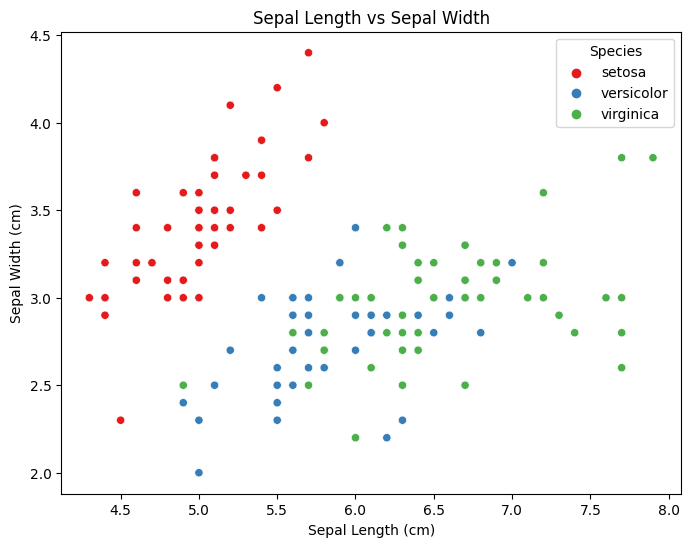

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na

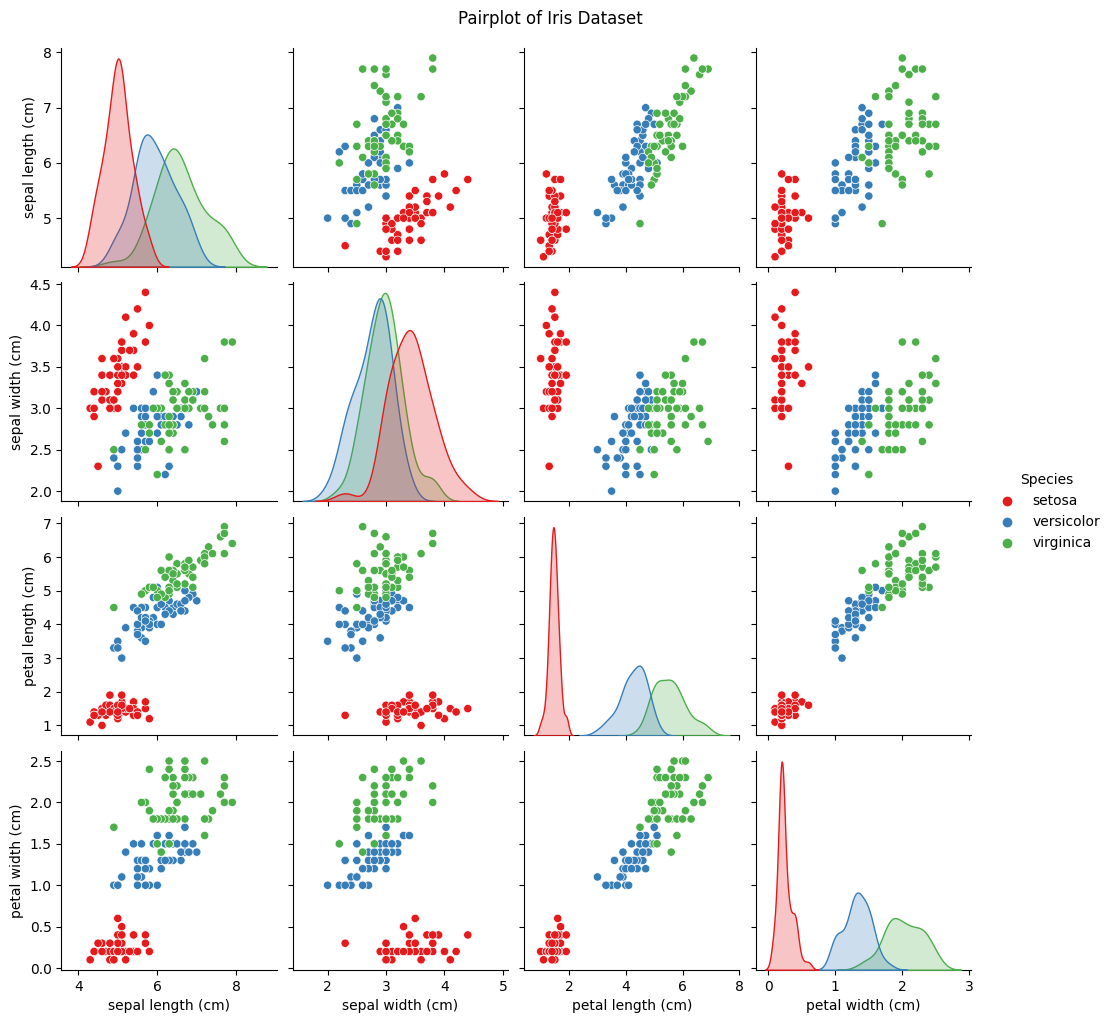

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


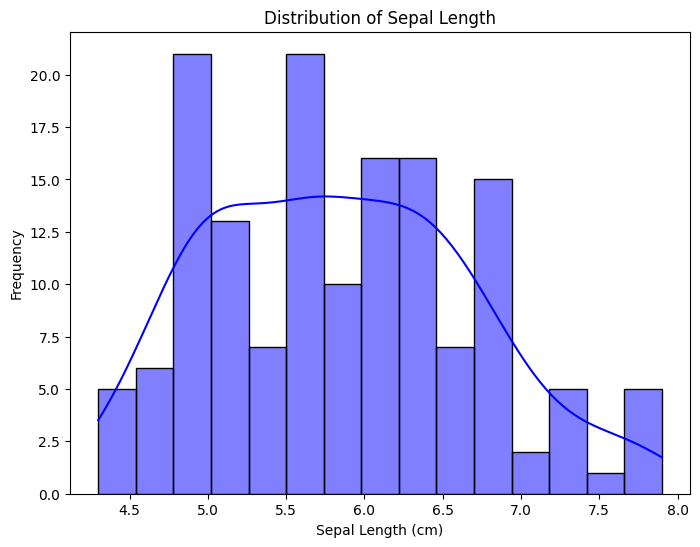

In [4]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)", hue="Species", palette="Set1")
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title='Species')
plt.show()

# Pairplot
sns.pairplot(df, hue="Species", palette="Set1")
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

# Histogram of Sepal Length
plt.figure(figsize=(8, 6))
sns.histplot(df["sepal length (cm)"], kde=True, color="blue", bins=15)
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.show()

In [5]:
# Visualizing the House Prices Dataset
import pandas as pd

# Loading the dataset
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Display the first few rows of the dataset to understand its structure
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


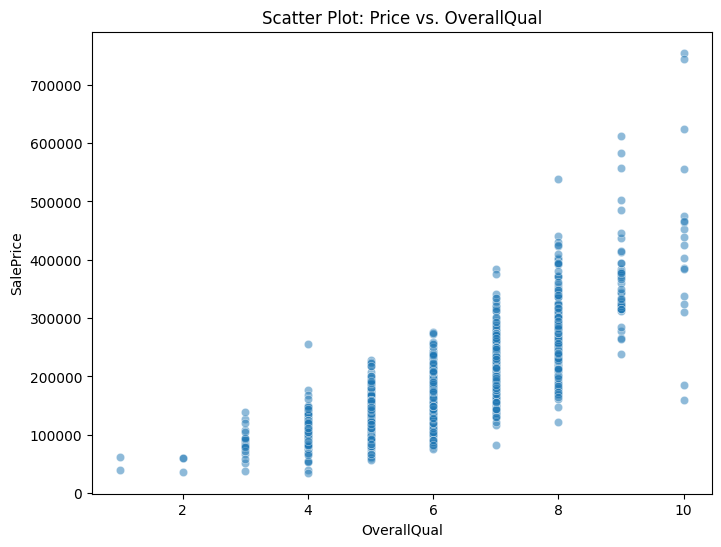

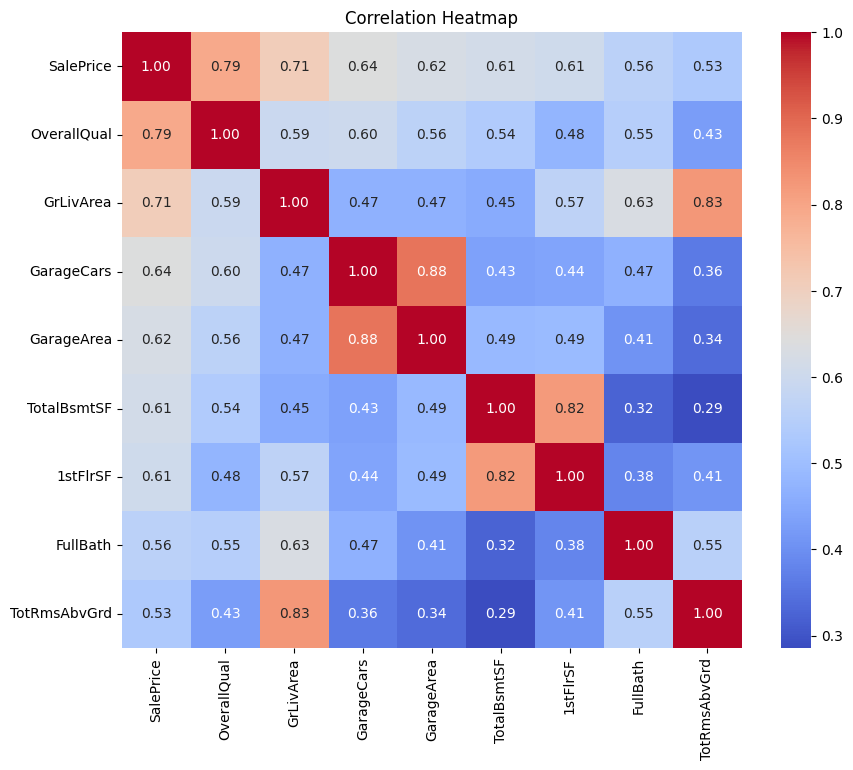

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


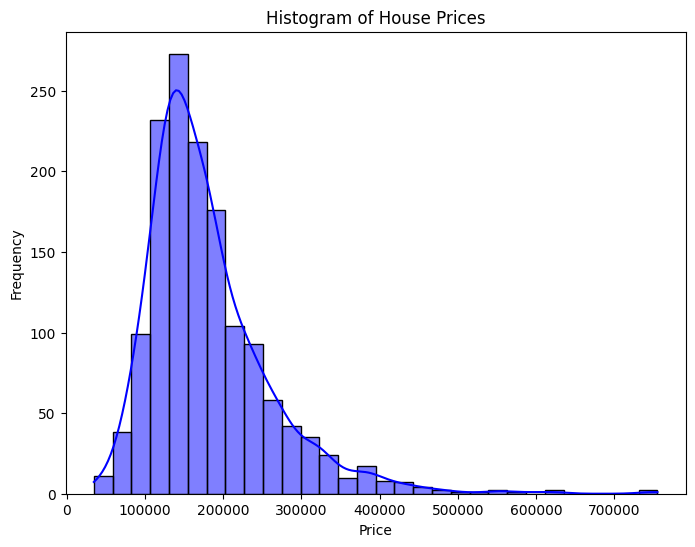

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation and visualization
numerical_columns = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                     'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd'] # Used columns with high correlation to price

# Scatter plot: Price vs Sqft Living
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='OverallQual', y='SalePrice', alpha=0.5)
plt.title('Scatter Plot: Price vs. OverallQual')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

# Heatmap of correlations
plt.figure(figsize=(10, 8))
correlation_matrix = data[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Histogram of house prices
plt.figure(figsize=(8, 6))
sns.histplot(data['SalePrice'], bins=30, kde=True, color='blue')
plt.title('Histogram of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Problem 3: Create a model for Iris using all three objective variables
Create a model that can classify all three types included in train.csvthe target variable in the Iris dataset .Species

In [7]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_iris
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

# Load the Iris dataset
iris_data = load_iris()
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["Species"] = pd.Categorical.from_codes(iris_data.target, iris_data.target_names)

# Separate features and target variable
X = df[iris_data.feature_names].values
y = df["Species"].values

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Define the model
model = Sequential([
    Input(shape=(4,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(X_train, y_train_onehot, epochs=50, batch_size=8, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_onehot)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predict on the test set
y_pred = model.predict(X_test)
predicted_classes = tf.argmax(y_pred, axis=1).numpy()
predicted_species = label_encoder.inverse_transform(predicted_classes)

# Display some predictions
for i in range(5):
    print(f"Actual: {label_encoder.inverse_transform([y_test[i]])[0]}, Predicted: {predicted_species[i]}")


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6652 - loss: 0.9778 - val_accuracy: 0.3333 - val_loss: 1.0043
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6464 - loss: 0.8469 - val_accuracy: 0.5000 - val_loss: 0.8730
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7094 - loss: 0.7427 - val_accuracy: 0.5000 - val_loss: 0.7873
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6719 - loss: 0.6851 - val_accuracy: 0.5000 - val_loss: 0.7313
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5662 - val_accuracy: 0.5000 - val_loss: 0.6498
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7155 - loss: 0.5798 - val_accuracy: 0.5833 - val_loss: 0.6061
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7482 - loss: 0.5348 - val_accuracy: 0.5000 - val_loss: 0.5913
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7644 - loss: 0.4695 - val_accuracy: 1.0000 - val_loss

# Create a model for House Prices
Build a model using the House Prices regression data set and consider the difference between classification and regression problems.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the dataset
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Step 2: Inspect the data
print(data.head())
print(data.info())

# Step 3: Select variables and handle missing values
# Use 'GrLivArea' and 'YearBuilt' as explanatory variables
selected_features = ['GrLivArea', 'YearBuilt']
X = data[selected_features]
y = data['SalePrice']

# Check for missing values
print(X.isnull().sum())
print(y.isnull().sum())

# Drop rows with missing values (if any)
data_cleaned = data.dropna(subset=selected_features + ['SalePrice'])
X = data_cleaned[selected_features]
y = data_cleaned['SalePrice']

# Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train a regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate the model
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Display the model coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

# Question 5: Create an MNIST model
Create a model to classify MNIST using the neural network Scratch. It is similar to the previous Iris in that it classifies three or more classes. The difference is that the input is an image.

We aim to recreate the model implemented from Scratch.

In [9]:
# Classify MNIST using neural network Scratch
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten the images (28x28 -> 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

# Step 2: Define the neural network architecture
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        return z * (1 - z)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, x):
        self.z1 = np.dot(x, self.weights_input_hidden) + self.bias_hidden
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.weights_hidden_output) + self.bias_output
        self.a2 = self.softmax(self.z2)
        return self.a2

    def backward(self, x, y, output):
        m = x.shape[0]
        d_z2 = output - y
        self.d_weights_hidden_output = np.dot(self.a1.T, d_z2) / m
        self.d_bias_output = np.sum(d_z2, axis=0, keepdims=True) / m

        d_a1 = np.dot(d_z2, self.weights_hidden_output.T)
        d_z1 = d_a1 * self.sigmoid_derivative(self.a1)
        self.d_weights_input_hidden = np.dot(x.T, d_z1) / m
        self.d_bias_hidden = np.sum(d_z1, axis=0, keepdims=True) / m

    def update_parameters(self, learning_rate):
        self.weights_input_hidden -= learning_rate * self.d_weights_input_hidden
        self.bias_hidden -= learning_rate * self.d_bias_hidden
        self.weights_hidden_output -= learning_rate * self.d_weights_hidden_output
        self.bias_output -= learning_rate * self.d_bias_output

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/10, Loss: 2.3048875205323216
Epoch 2/10, Loss: 2.3046464374614124
Epoch 3/10, Loss: 2.304420128425399
Epoch 4/10, Loss: 2.304207619086435
Epoch 5/10, Loss: 2.3040079996409735
Epoch 6/10, Loss: 2.3038204205154917
Epoch 7/10, Loss: 2.303644088353506
Epoch 8/10, Loss: 2.3034782622735164
Epoch 9/10, Loss: 2.3033222503790145
Epoch 10/10, Loss: 2.3031754065031267
Test Accuracy: 9.82%


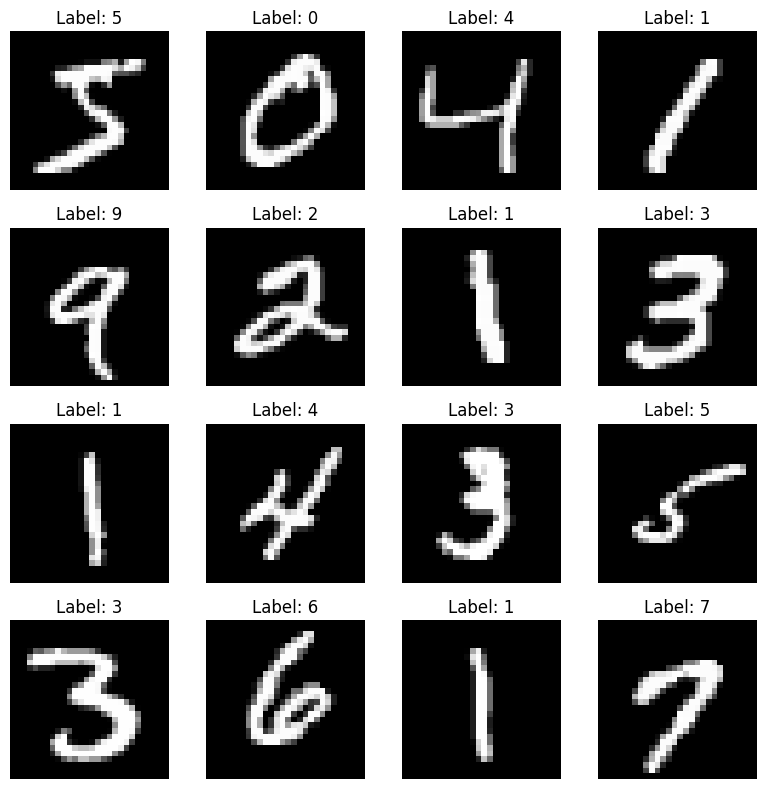

In [10]:
# Step 3: Train the model
input_size = 784
hidden_size = 128
output_size = 10
learning_rate = 0.01
epochs = 10

nn = NeuralNetwork(input_size, hidden_size, output_size)

for epoch in range(epochs):
    output = nn.forward(x_train)
    nn.backward(x_train, y_train, output)
    nn.update_parameters(learning_rate)

    # Compute the loss (cross-entropy)
    loss = -np.mean(np.sum(y_train * np.log(output + 1e-8), axis=1))
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss}")

# Step 4: Evaluate the model
output_test = nn.forward(x_test)
predictions = np.argmax(output_test, axis=1)
labels = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Function to display a grid of MNIST images
def visualize_data(images, labels, num_samples=16):
    plt.figure(figsize=(8, 8))
    for i in range(num_samples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display 16 images from the training dataset
visualize_data(x_train[:16].reshape(-1, 28, 28), np.argmax(y_train[:16], axis=1))